# Books to Scrape — Data Collection, Cleaning & Exploratory Data Analysis

## Project Overview

This project collects book information from the Books to Scrape website using Scrapy,
performs data cleaning and quality checks using Pandas, creates engineered features,
and conducts exploratory data analysis to identify patterns in book prices, ratings,
availability, categories, and value.

### Objectives

- Scrape book information from multiple catalog pages.
- Collect at least 100 books.
- Perform data quality checks and cleaning.
- Engineer useful analytical features.
- Explore price, rating, stock, reviews, and category patterns.
- Develop a rule-based recommendation feature.
- Generate visualizations and insights from the collected dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("data/raw_books.csv")

df.head()

,title,category,price,rating,availability,description,UPC,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,star-rating Two,In stock (19 available)\n \n\n \n \n ...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,star-rating Two,In stock (19 available)\n \n\n \n \n ...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,star-rating One,In stock (19 available)\n \n\n \n \n ...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,star-rating One,In stock (19 available)\n \n\n \n \n ...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,star-rating Three,In stock (19 available)\n \n\n \n \n ...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 100
Number of columns: 9


In [4]:
print(df.columns.tolist())

['title', 'category', 'price', 'rating', 'availability', 'description', 'UPC', 'number_of_reviews', 'product_url']


In [5]:
# CHECK MISSING VALUES
missing_values = df.isnull().sum()

print(missing_values)

title                0
category             0
price                0
rating               0
availability         0
description          0
UPC                  0
number_of_reviews    0
product_url          0
dtype: int64


In [6]:
# CHECK DUPLICATE UPCS
duplicate_upcs = df["UPC"].duplicated().sum()

print("Duplicate UPCs:", duplicate_upcs)

Duplicate UPCs: 0


In [7]:
# CHECK DUPLICATE ROWS
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   title              100 non-null    str  
 1   category           100 non-null    str  
 2   price              100 non-null    str  
 3   rating             100 non-null    str  
 4   availability       100 non-null    str  
 5   description        100 non-null    str  
 6   UPC                100 non-null    str  
 7   number_of_reviews  100 non-null    int64
 8   product_url        100 non-null    str  
dtypes: int64(1), str(8)
memory usage: 7.2 KB


In [9]:
print("Duplicate UPCs:", df["UPC"].duplicated().sum())
print("Duplicate rows:", df.duplicated().sum())

Duplicate UPCs: 0
Duplicate rows: 0


In [10]:
# DATA PREPROCESSING
cleaned_df = df.copy()

print("Original rows:", len(df))
print("Cleaned dataset rows:", len(cleaned_df))

Original rows: 100
Cleaned dataset rows: 100


In [11]:
# CLEAN THE TEXT COLUMNS
text_columns = [
    "title",
    "category",
    "availability",
    "description",
    "UPC",
    "product_url"
]

for col in text_columns:
    cleaned_df[col] = cleaned_df[col].str.strip()

print("Text cleaning completed.")

Text cleaning completed.


In [12]:
cleaned_df["price"] = (
    cleaned_df["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

In [13]:
print(cleaned_df["price"].head())
print(cleaned_df["price"].dtype)

0    45.17
1    51.33
2    37.59
3    23.88
4    57.25
Name: price, dtype: float64
float64


In [14]:
print(cleaned_df["rating"].unique())

<StringArray>
[  'star-rating Two',   'star-rating One', 'star-rating Three',
  'star-rating Five',  'star-rating Four']
Length: 5, dtype: str


In [15]:
print(cleaned_df["rating"].unique())

<StringArray>
[  'star-rating Two',   'star-rating One', 'star-rating Three',
  'star-rating Five',  'star-rating Four']
Length: 5, dtype: str


In [16]:
# CONVERT RATING TO NUMERIC
rating_map = {
    "star-rating One": 1,
    "star-rating Two": 2,
    "star-rating Three": 3,
    "star-rating Four": 4,
    "star-rating Five": 5
}

cleaned_df["rating"] = cleaned_df["rating"].map(rating_map)

In [17]:
print(cleaned_df["rating"].unique())
print(cleaned_df["rating"].dtype)

[2 1 3 5 4]
int64


In [18]:
print(cleaned_df["availability"].head(10).to_list())

['In stock (19 available)\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock', 'In stock (19 available)\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock', 'In stock (19 available)\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock', 'In stock (19 available)\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    \n        In stock\n    \n\n    \n    

In [19]:
import re

cleaned_df["stock_count"] = cleaned_df["availability"].str.extract(
    r"\((\d+)\s+available\)"
)[0].astype(int)

In [20]:
print(cleaned_df[["availability", "stock_count"]].head())

                                        availability  stock_count
0  In stock (19 available)\n    \n\n    \n    \n ...           19
1  In stock (19 available)\n    \n\n    \n    \n ...           19
2  In stock (19 available)\n    \n\n    \n    \n ...           19
3  In stock (19 available)\n    \n\n    \n    \n ...           19
4  In stock (19 available)\n    \n\n    \n    \n ...           19


In [21]:
print(cleaned_df["stock_count"].dtype)

int64


In [22]:
# CLEAN THE DESCRIPTION 
print(cleaned_df["description"].head(3).to_list())

['“Wherever you go, whatever you do, just . . . don’t do anything stupid.” —My MotherDuring her yearlong adventure backpacking from South Africa to Singapore, S. Bedford definitely did a few things her mother might classify as "stupid." She swam with great white sharks in South Africa, ran from lions in Zimbabwe, climbed a Himalayan mountain without training in Nepal, and wa “Wherever you go, whatever you do, just . . . don’t do anything stupid.” —My MotherDuring her yearlong adventure backpacking from South Africa to Singapore, S. Bedford definitely did a few things her mother might classify as "stupid." She swam with great white sharks in South Africa, ran from lions in Zimbabwe, climbed a Himalayan mountain without training in Nepal, and watched as her friend was attacked by a monkey in Indonesia.But interspersed in those slightly more crazy moments, Sue Bedfored and her friend "Sara the Stoic" experienced the sights, sounds, life, and culture of fifteen countries. Joined along the 

In [23]:
cleaned_df["description"] = (
    cleaned_df["description"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [24]:
# CLEAN TITLE
cleaned_df["title"] = (
    cleaned_df["title"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [25]:
# CATEGORY CLEANING
cleaned_df["category"] = (
    cleaned_df["category"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [26]:
display(
    cleaned_df[
        ["title", "category", "price", "rating", "stock_count", "description"]
    ].head(5)
)

,title,category,price,rating,stock_count,description
0,It's Only the Himalayas,Travel,45.17,2,19,"“Wherever you go, whatever you do, just . . . ..."
1,Libertarianism for Beginners,Politics,51.33,2,19,Libertarianism isn't about winning elections; ...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,19,"Andrew Barger, award-winning author and engine..."
3,Olio,Poetry,23.88,1,19,"Part fact, part fiction, Tyehimba Jess's much ..."
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,19,This is the never-before-told story of the mus...


In [27]:
def get_price_band(price):
    if price < 20:
        return "Cheap"
    elif price <= 40:
        return "Medium"
    else:
        return "Expensive"


cleaned_df["price_band"] = cleaned_df["price"].apply(get_price_band)

In [28]:
print(cleaned_df["price_band"].value_counts())

price_band
Expensive    40
Medium       34
Cheap        26
Name: count, dtype: int64


In [29]:
cleaned_df["affordability_score"] = (
    1 / (1 + cleaned_df["price"])
)

In [30]:
display(
    cleaned_df[
        ["title", "price", "price_band", "affordability_score"]
    ].head(10)
)

,title,price,price_band,affordability_score
0,It's Only the Himalayas,45.17,Expensive,0.021659
1,Libertarianism for Beginners,51.33,Expensive,0.019109
2,Mesaerion: The Best Science Fiction Stories 18...,37.59,Medium,0.025913
3,Olio,23.88,Medium,0.040193
4,Our Band Could Be Your Life: Scenes from the A...,57.25,Expensive,0.017167
5,Rip it Up and Start Again,35.02,Medium,0.027762
6,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,Expensive,0.018765
7,Set Me Free,17.46,Cheap,0.054171
8,Shakespeare's Sonnets,20.66,Medium,0.046168
9,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,Cheap,0.066711


In [31]:
print("Minimum affordability score:",
      cleaned_df["affordability_score"].min())

print("Maximum affordability score:",
      cleaned_df["affordability_score"].max())

Minimum affordability score: 0.01691761123329386
Maximum affordability score: 0.08960573476702509


In [32]:
# VALUE SCORE
cleaned_df["rating_score"] = (
    (cleaned_df["rating"] - 1) / 4
)

cleaned_df["value_score"] = (
    0.6 * cleaned_df["rating_score"]
    + 0.4 * cleaned_df["affordability_score"]
)

In [33]:
display(
    cleaned_df[
        [
            "title",
            "price",
            "rating",
            "affordability_score",
            "value_score"
        ]
    ].head(10)
)

,title,price,rating,affordability_score,value_score
0,It's Only the Himalayas,45.17,2,0.021659,0.158664
1,Libertarianism for Beginners,51.33,2,0.019109,0.157644
2,Mesaerion: The Best Science Fiction Stories 18...,37.59,1,0.025913,0.010365
3,Olio,23.88,1,0.040193,0.016077
4,Our Band Could Be Your Life: Scenes from the A...,57.25,3,0.017167,0.306867
5,Rip it Up and Start Again,35.02,5,0.027762,0.611105
6,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5,0.018765,0.607506
7,Set Me Free,17.46,5,0.054171,0.621668
8,Shakespeare's Sonnets,20.66,4,0.046168,0.468467
9,"Starving Hearts (Triangular Trade Trilogy, #1)",13.99,2,0.066711,0.176684


In [34]:
print("Minimum value score:",
      cleaned_df["value_score"].min())

print("Maximum value score:",
      cleaned_df["value_score"].max())

Minimum value score: 0.0069674272774777925
Maximum value score: 0.6278940027894002


In [35]:
# IMPROVE SCORE
cleaned_df["affordability_norm"] = (
    (cleaned_df["affordability_score"] -
     cleaned_df["affordability_score"].min())
    /
    (cleaned_df["affordability_score"].max() -
     cleaned_df["affordability_score"].min())
)

In [36]:
cleaned_df["value_score"] = (
    0.6 * cleaned_df["rating_score"]
    + 0.4 * cleaned_df["affordability_norm"]
)

In [37]:
print("Minimum value score:",
      cleaned_df["value_score"].min())

print("Maximum value score:",
      cleaned_df["value_score"].max())

Minimum value score: 0.0027567472431347015
Maximum value score: 0.8906521350255889


In [38]:
cleaned_df["recommended"] = (
    (cleaned_df["rating"] >= 4)
    & (cleaned_df["value_score"] >= 0.5)
)

In [39]:
print(cleaned_df["recommended"].value_counts())

recommended
False    72
True     28
Name: count, dtype: int64


In [40]:
display(
    cleaned_df[
        cleaned_df["recommended"] == True
    ][
        [
            "title",
            "price",
            "rating",
            "price_band",
            "value_score",
            "recommended"
        ]
    ].head(10)
)

,title,price,rating,price_band,value_score,recommended
5,Rip it Up and Start Again,35.02,5,Medium,0.659678,True
6,Scott Pilgrim's Precious Little Life (Scott Pi...,52.29,5,Expensive,0.610167,True
7,Set Me Free,17.46,5,Cheap,0.805005,True
8,Shakespeare's Sonnets,20.66,4,Medium,0.610964,True
11,The Boys in the Boat: Nine Americans and Their...,22.60,4,Medium,0.590079,True
13,The Dirty Little Secrets of Getting Your Dream...,33.34,4,Medium,0.517152,True
15,Sapiens: A Brief History of Humankind,54.23,5,Expensive,0.606540,True
21,Sophie's World,15.94,5,Cheap,0.831753,True
23,The Elephant Tree,23.82,5,Medium,0.728618,True
25,The Four Agreements: A Practical Guide to Pers...,17.66,5,Cheap,0.801810,True


In [41]:
print(cleaned_df.columns.tolist())

['title', 'category', 'price', 'rating', 'availability', 'description', 'UPC', 'number_of_reviews', 'product_url', 'stock_count', 'price_band', 'affordability_score', 'rating_score', 'value_score', 'affordability_norm', 'recommended']


In [42]:
print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])

Rows: 100
Columns: 16


In [43]:
print(cleaned_df.columns.tolist())

['title', 'category', 'price', 'rating', 'availability', 'description', 'UPC', 'number_of_reviews', 'product_url', 'stock_count', 'price_band', 'affordability_score', 'rating_score', 'value_score', 'affordability_norm', 'recommended']


In [44]:
cleaned_df["description_word_count"] = (
    cleaned_df["description"]
    .str.split()
    .str.len()
)

In [45]:
print(cleaned_df.columns.tolist())
print("Rows:", cleaned_df.shape[0])
print("Columns:", cleaned_df.shape[1])

['title', 'category', 'price', 'rating', 'availability', 'description', 'UPC', 'number_of_reviews', 'product_url', 'stock_count', 'price_band', 'affordability_score', 'rating_score', 'value_score', 'affordability_norm', 'recommended', 'description_word_count']
Rows: 100
Columns: 17


In [46]:
display(
    cleaned_df[
        ["title", "description_word_count"]
    ].head(10)
)

,title,description_word_count
0,It's Only the Himalayas,230
1,Libertarianism for Beginners,195
2,Mesaerion: The Best Science Fiction Stories 18...,283
3,Olio,249
4,Our Band Could Be Your Life: Scenes from the A...,163
5,Rip it Up and Start Again,148
6,Scott Pilgrim's Precious Little Life (Scott Pi...,148
7,Set Me Free,132
8,Shakespeare's Sonnets,143
9,"Starving Hearts (Triangular Trade Trilogy, #1)",196


In [47]:
print(cleaned_df.isnull().sum())

title                     0
category                  0
price                     0
rating                    0
availability              0
description               0
UPC                       0
number_of_reviews         0
product_url               0
stock_count               0
price_band                0
affordability_score       0
rating_score              0
value_score               0
affordability_norm        0
recommended               0
description_word_count    0
dtype: int64


In [48]:
cleaned_df.to_csv(
    "data/cleaned_books.csv",
    index=False,
    encoding="utf-8"
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [49]:
final_df = pd.read_csv("data/cleaned_books.csv")

print("Rows:", final_df.shape[0])
print("Columns:", final_df.shape[1])

Rows: 100
Columns: 17


In [50]:
#EDA
final_df.describe()

,price,rating,number_of_reviews,stock_count,affordability_score,rating_score,value_score,affordability_norm,description_word_count
count,100.000000,100.000000,100.0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,34.560700,2.930000,0.0,17.180000,0.034509,0.482500,0.386302,0.242005,224.710000
std,14.638531,1.423149,0.0,1.479694,0.016819,0.355787,0.242499,0.231383,107.798474
min,10.160000,1.000000,0.0,16.000000,0.016918,0.000000,0.002757,0.000000,36.000000
25%,19.897500,2.000000,0.0,16.000000,0.020422,0.250000,0.179702,0.048215,163.750000
50%,34.775000,3.000000,0.0,16.000000,0.027954,0.500000,0.356807,0.151829,211.500000
75%,47.967500,4.000000,0.0,19.000000,0.047853,0.750000,0.598757,0.425588,276.500000
max,58.110000,5.000000,0.0,22.000000,0.089606,1.000000,0.890652,1.000000,722.000000


In [51]:
final_df[
    [
        "price",
        "rating",
        "number_of_reviews",
        "stock_count"
    ]
].describe()

,price,rating,number_of_reviews,stock_count
count,100.000000,100.000000,100.0,100.000000
mean,34.560700,2.930000,0.0,17.180000
std,14.638531,1.423149,0.0,1.479694
min,10.160000,1.000000,0.0,16.000000
25%,19.897500,2.000000,0.0,16.000000
50%,34.775000,3.000000,0.0,16.000000
75%,47.967500,4.000000,0.0,19.000000
max,58.110000,5.000000,0.0,22.000000


In [52]:
#AVERAGE VALUE
print("Average price:", final_df["price"].mean())
print("Average rating:", final_df["rating"].mean())
print("Average reviews:", final_df["number_of_reviews"].mean())
print("Average stock:", final_df["stock_count"].mean())

Average price: 34.560700000000004
Average rating: 2.93
Average reviews: 0.0
Average stock: 17.18


In [53]:
print("Median price:", final_df["price"].median())
print("Median rating:", final_df["rating"].median())
print("Median reviews:", final_df["number_of_reviews"].median())
print("Median stock:", final_df["stock_count"].median())

Median price: 34.775000000000006
Median rating: 3.0
Median reviews: 0.0
Median stock: 16.0


In [54]:
category_counts = final_df["category"].value_counts()

print(category_counts)

category
Sequential Art        14
Nonfiction            12
Default                9
Poetry                 7
Food and Drink         5
Add a comment          5
Fiction                5
Young Adult            4
History                4
Fantasy                4
Music                  3
Thriller               3
Mystery                3
Childrens              3
Science Fiction        2
Philosophy             2
Spirituality           2
Romance                2
Travel                 1
Politics               1
Business               1
Art                    1
Contemporary           1
New Adult              1
Horror                 1
Health                 1
Self Help              1
Science                1
Historical Fiction     1
Name: count, dtype: int64


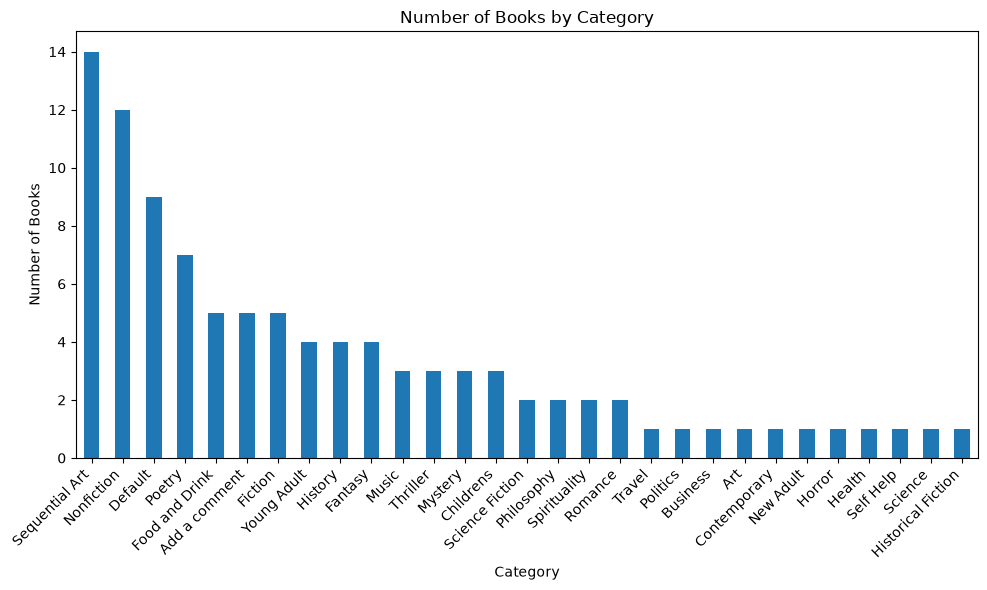

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

category_counts.plot(kind="bar")

plt.title("Number of Books by Category")
plt.xlabel("Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

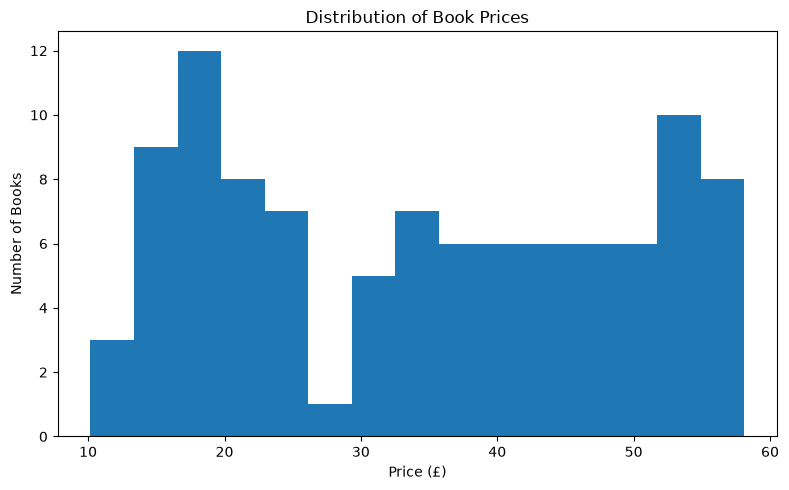

In [56]:
# PRICE DISTRIBUTION
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(final_df["price"], bins=15)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

In [57]:
#RATING DISTRIBUTION
rating_counts = final_df["rating"].value_counts().sort_index()

print(rating_counts)

rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64


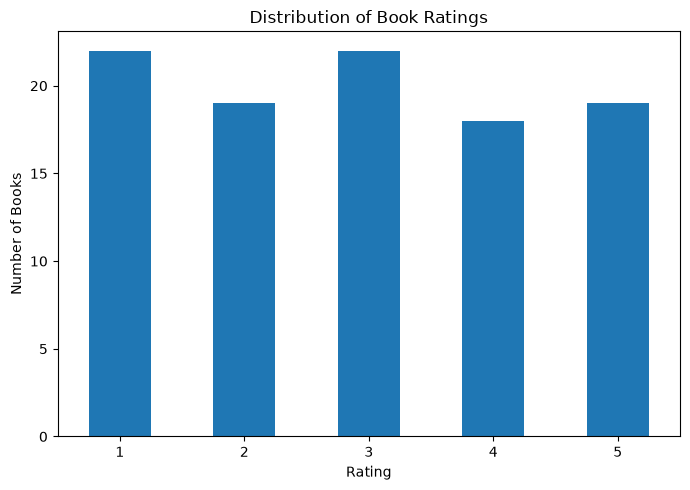

In [58]:
plt.figure(figsize=(7, 5))

rating_counts.plot(kind="bar")

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

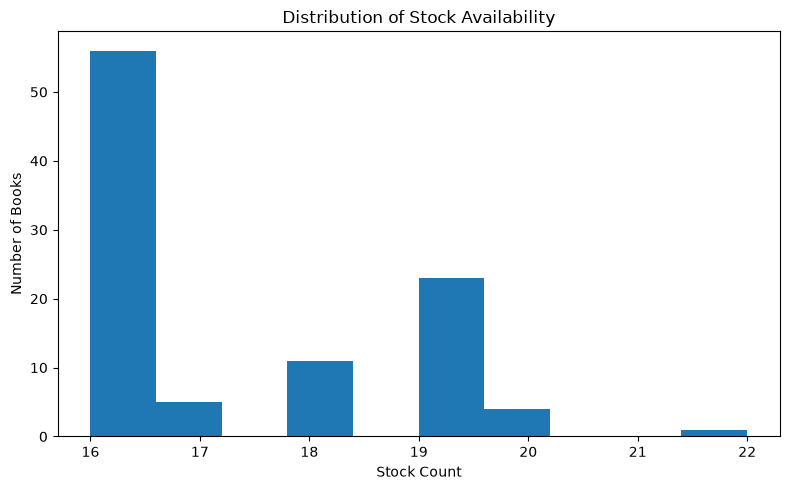

In [59]:
# STOCK DISTRIBUTION
plt.figure(figsize=(8, 5))

plt.hist(final_df["stock_count"], bins=10)

plt.title("Distribution of Stock Availability")
plt.xlabel("Stock Count")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

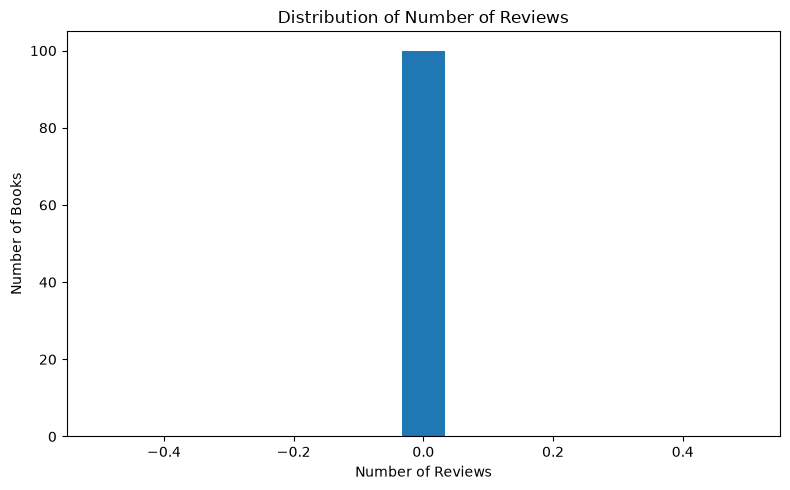

In [60]:
# NO. OF REVIEWS DISTRIBUTION
plt.figure(figsize=(8, 5))

plt.hist(final_df["number_of_reviews"], bins=15)

plt.title("Distribution of Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.show()

In [61]:
# PRICE BAND DISTRIBUTION
price_band_counts = final_df["price_band"].value_counts()

print(price_band_counts)

price_band
Expensive    40
Medium       34
Cheap        26
Name: count, dtype: int64


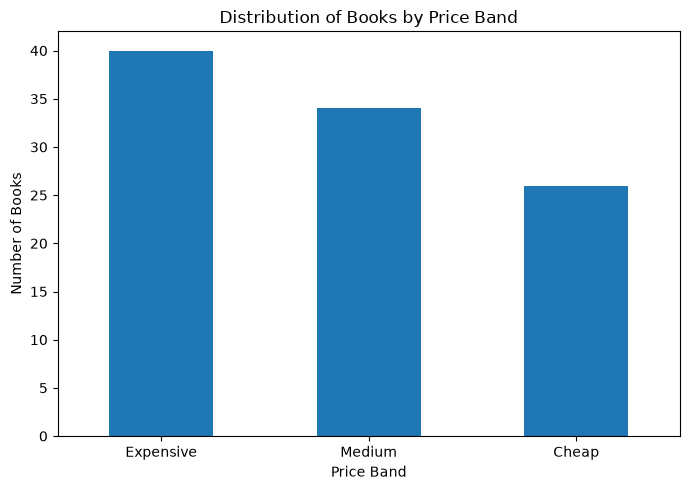

In [62]:
plt.figure(figsize=(7, 5))

price_band_counts.plot(kind="bar")

plt.title("Distribution of Books by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Number of Books")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

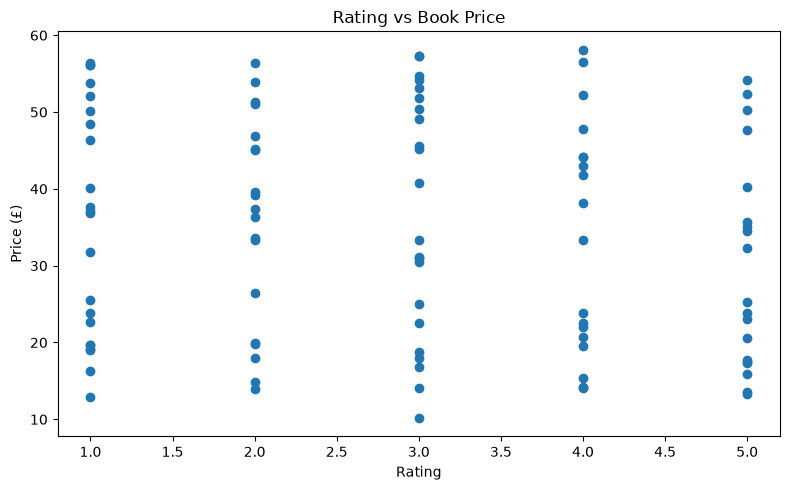

In [63]:
# RATING VS. PRICE SCATTER PLOT
plt.figure(figsize=(8, 5))

plt.scatter(
    final_df["rating"],
    final_df["price"]
)

plt.title("Rating vs Book Price")
plt.xlabel("Rating")
plt.ylabel("Price (£)")

plt.tight_layout()
plt.show()

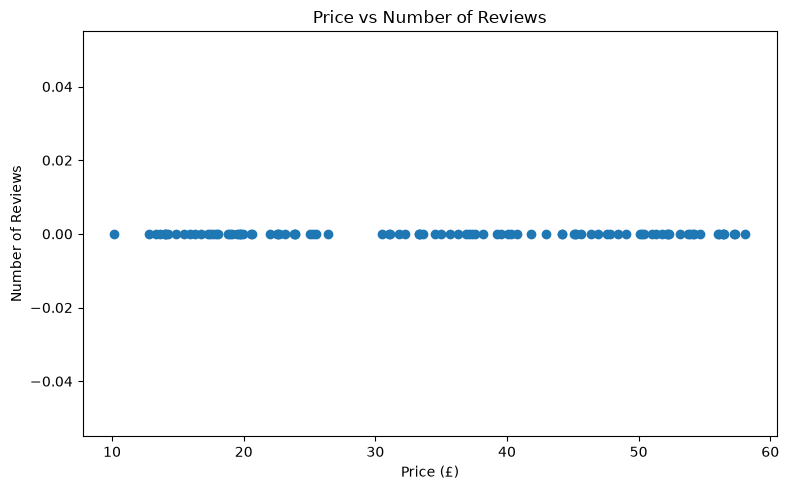

In [64]:
# PRICE VS Number of Reviews SCATTER PLOT
plt.figure(figsize=(8, 5))

plt.scatter(
    final_df["price"],
    final_df["number_of_reviews"]
)

plt.title("Price vs Number of Reviews")
plt.xlabel("Price (£)")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [65]:
# CORRELATION analysis
corr_columns = [
    "price",
    "rating",
    "number_of_reviews",
    "stock_count",
    "description_word_count",
    "affordability_score",
    "value_score"
]

correlation_matrix = final_df[corr_columns].corr()

print(correlation_matrix.round(2))

                        price  rating  number_of_reviews  stock_count  \
price                    1.00   -0.12                NaN         0.11   
rating                  -0.12    1.00                NaN         0.06   
number_of_reviews         NaN     NaN                NaN          NaN   
stock_count              0.11    0.06                NaN         1.00   
description_word_count   0.00   -0.12                NaN        -0.02   
affordability_score     -0.93    0.12                NaN        -0.12   
value_score             -0.46    0.93                NaN         0.01   

                        description_word_count  affordability_score  \
price                                     0.00                -0.93   
rating                                   -0.12                 0.12   
number_of_reviews                          NaN                  NaN   
stock_count                              -0.02                -0.12   
description_word_count                    1.00              

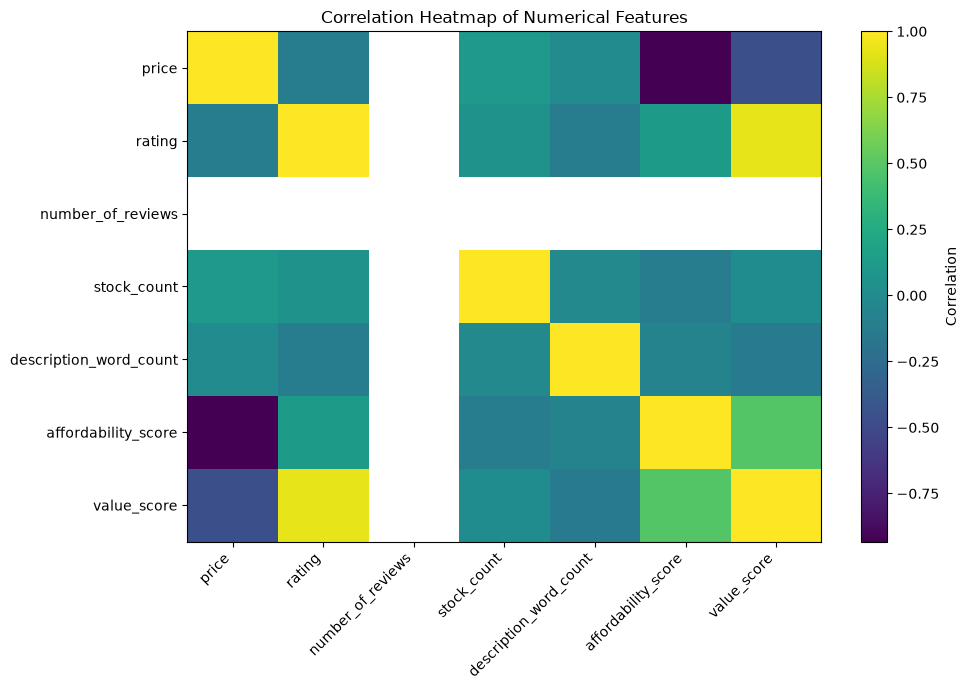

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_columns)),
    corr_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_columns)),
    corr_columns
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

In [67]:
# STRONG CORRELATIONS
corr_pairs = (
    correlation_matrix
    .where(
        ~correlation_matrix.eq(1)
    )
    .stack()
    .sort_values()
)

print("Strongest negative relationships:")
print(corr_pairs.head(5))

print("\nStrongest positive relationships:")
print(corr_pairs.tail(5))

Strongest negative relationships:
price                   affordability_score   -0.931923
affordability_score     price                 -0.931923
value_score             price                 -0.462850
price                   value_score           -0.462850
description_word_count  value_score           -0.130034
dtype: float64

Strongest positive relationships:
description_word_count  description_word_count   NaN
affordability_score     number_of_reviews        NaN
                        affordability_score      NaN
value_score             number_of_reviews        NaN
                        value_score              NaN
dtype: float64


In [68]:
# UNIQUE CATEGORIES
import numpy as np

upper_triangle = correlation_matrix.where(
    np.triu(
        np.ones(correlation_matrix.shape),
        k=1
    ).astype(bool)
)

unique_pairs = (
    upper_triangle
    .stack()
    .sort_values()
)

print("Strongest negative relationships:")
print(unique_pairs.head(5))

print("\nStrongest positive relationships:")
print(unique_pairs.tail(5))

Strongest negative relationships:
price                   affordability_score   -0.931923
                        value_score           -0.462850
description_word_count  value_score           -0.130034
stock_count             affordability_score   -0.122312
price                   rating                -0.121741
dtype: float64

Strongest positive relationships:
value_score  number_of_reviews        NaN
             stock_count              NaN
             description_word_count   NaN
             affordability_score      NaN
             value_score              NaN
dtype: float64


In [69]:
price_rating_corr = final_df["price"].corr(
    final_df["rating"]
)

print("Price-Rating correlation:",
      price_rating_corr)

Price-Rating correlation: -0.12174127007413636


In [70]:
# PRICE VS Reviews
price_reviews_corr = final_df["price"].corr(
    final_df["number_of_reviews"]
)

print(
    "Price-Reviews correlation:",
    price_reviews_corr
)

Price-Reviews correlation: nan


c:\Users\rachi\miniconda3\envs\ml\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\rachi\miniconda3\envs\ml\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [71]:
rating_reviews_corr = final_df["rating"].corr(
    final_df["number_of_reviews"]
)

print(
    "Rating-Reviews correlation:",
    rating_reviews_corr
)

Rating-Reviews correlation: nan


In [72]:
print("Price-Rating correlation:",
      final_df["price"].corr(final_df["rating"]))

print("Price-Reviews correlation:",
      final_df["price"].corr(final_df["number_of_reviews"]))

print("Rating-Reviews correlation:",
      final_df["rating"].corr(final_df["number_of_reviews"]))

Price-Rating correlation: -0.12174127007413636
Price-Reviews correlation: nan
Rating-Reviews correlation: nan


In [73]:
print(final_df[
    [
        "price",
        "rating",
        "number_of_reviews",
        "stock_count",
        "description_word_count",
        "affordability_score",
        "value_score"
    ]
].nunique())

price                     99
rating                     5
number_of_reviews          1
stock_count                6
description_word_count    86
affordability_score       99
value_score               99
dtype: int64


In [74]:
# BEST BOOKS
top_books = final_df.sort_values(
    "value_score",
    ascending=False
).head(10)

display(
    top_books[
        [
            "title",
            "price",
            "rating",
            "price_band",
            "value_score",
            "recommended"
        ]
    ]
)

,title,price,rating,price_band,value_score,recommended
82,Princess Between Worlds (Wide-Awake Princess #5),13.34,5,Cheap,0.890652,True
83,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",13.61,5,Cheap,0.883560,True
21,Sophie's World,15.94,5,Cheap,0.831753,True
37,Thirst,17.27,5,Cheap,0.808105,True
7,Set Me Free,17.46,5,Cheap,0.805005,True
25,The Four Agreements: A Practical Guide to Pers...,17.66,5,Cheap,0.801810,True
62,The Inefficiency Assassin: Time Management Tac...,20.59,5,Medium,0.761788,True
88,#HigherSelfie: Wake Up Your Life. Free Your So...,23.11,5,Medium,0.735147,True
23,The Elephant Tree,23.82,5,Medium,0.728618,True
71,Mama Tried: Traditional Italian Cooking for th...,14.02,4,Cheap,0.723279,True


In [75]:
# RECOMMENDED BOOKS vs NON-RECOMMENDED BOOKS
print(
    final_df.groupby("recommended")[["price", "rating", "value_score"]]
    .mean()
)

                 price    rating  value_score
recommended                                  
False        37.501806  2.250000     0.267712
True         26.997857  4.678571     0.691247


In [76]:
category_rating = (
    final_df.groupby("category")["rating"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

display(category_rating)

,count,mean
category,,
Romance,2,5.000000
Spirituality,2,5.000000
Philosophy,2,4.500000
Business,1,4.000000
Art,1,4.000000
Science,1,4.000000
Fiction,5,3.800000
Thriller,3,3.333333
Music,3,3.333333


In [77]:
category_count = (
    final_df["category"]
    .value_counts()
)

print(category_count)

category
Sequential Art        14
Nonfiction            12
Default                9
Poetry                 7
Food and Drink         5
Add a comment          5
Fiction                5
Young Adult            4
History                4
Fantasy                4
Music                  3
Thriller               3
Mystery                3
Childrens              3
Science Fiction        2
Philosophy             2
Spirituality           2
Romance                2
Travel                 1
Politics               1
Business               1
Art                    1
Contemporary           1
New Adult              1
Horror                 1
Health                 1
Self Help              1
Science                1
Historical Fiction     1
Name: count, dtype: int64


In [78]:
#Average price by category
category_price = (
    final_df.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

display(category_price)

category
Historical Fiction    53.740000
Politics              51.330000
Childrens             49.220000
Health                49.050000
Self Help             46.350000
Travel                45.170000
New Adult             45.070000
Art                   44.180000
Fiction               43.872000
Music                 43.196667
Science               42.960000
Mystery               41.316667
Horror                39.250000
Philosophy            37.025000
Science Fiction       36.630000
Poetry                36.238571
Food and Drink        34.886000
History               33.940000
Business              33.340000
Nonfiction            32.482500
Sequential Art        31.906429
Contemporary          31.770000
Add a comment         30.342000
Romance               29.900000
Thriller              29.626667
Fantasy               28.385000
Default               26.847778
Young Adult           25.047500
Spirituality          24.950000
Name: price, dtype: float64

In [79]:
#recommended books by category
recommended_category = pd.crosstab(
    final_df["category"],
    final_df["recommended"]
)

display(recommended_category)

recommended,False,True
category,,
Add a comment,4,1
Art,1,0
Business,0,1
Childrens,3,0
Contemporary,1,0
Default,7,2
Fantasy,3,1
Fiction,2,3
Food and Drink,4,1


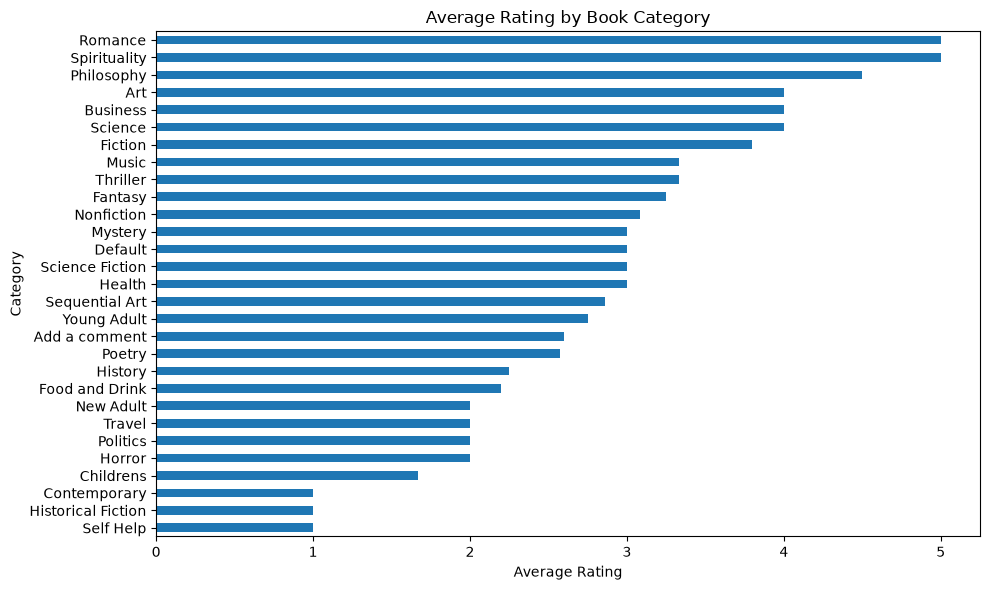

In [80]:
#AVERAge RATING BY CATOEGORY
plt.figure(figsize=(10, 6))

category_rating["mean"].sort_values().plot(kind="barh")

plt.title("Average Rating by Book Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

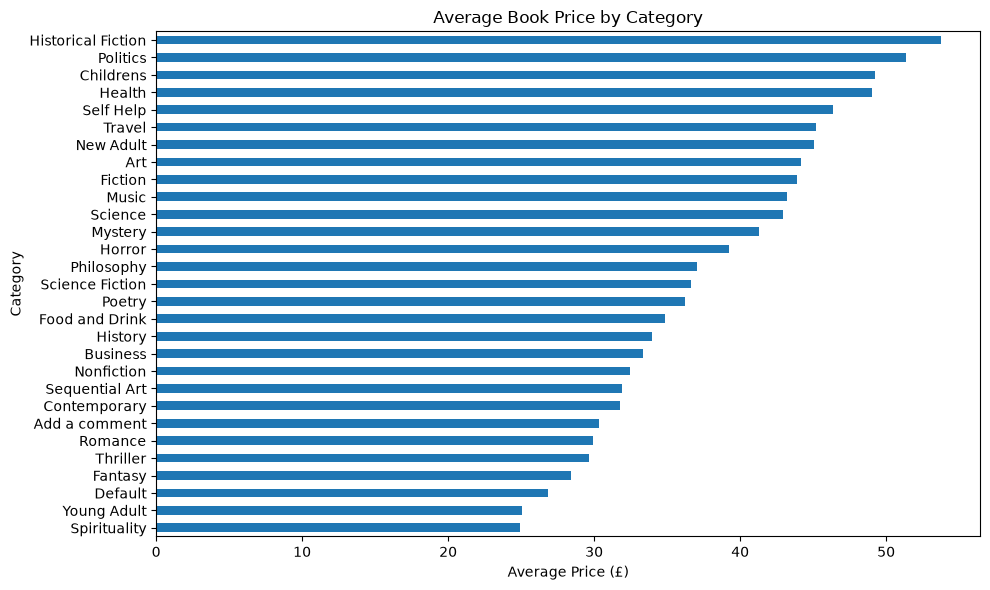

In [81]:
#AVERAGE PRICE BY CATEGORY
plt.figure(figsize=(10, 6))

category_price.sort_values().plot(kind="barh")

plt.title("Average Book Price by Category")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

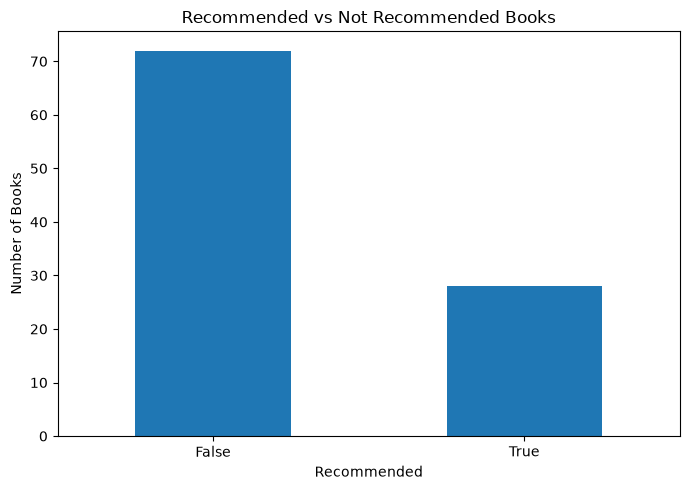

In [82]:
#REOCOMMENDED VS NON-RECOMMENDED 
recommendation_counts = final_df["recommended"].value_counts()

plt.figure(figsize=(7, 5))

recommendation_counts.plot(kind="bar")

plt.title("Recommended vs Not Recommended Books")
plt.xlabel("Recommended")
plt.ylabel("Number of Books")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [83]:
import os

print(os.getcwd())

d:\ML


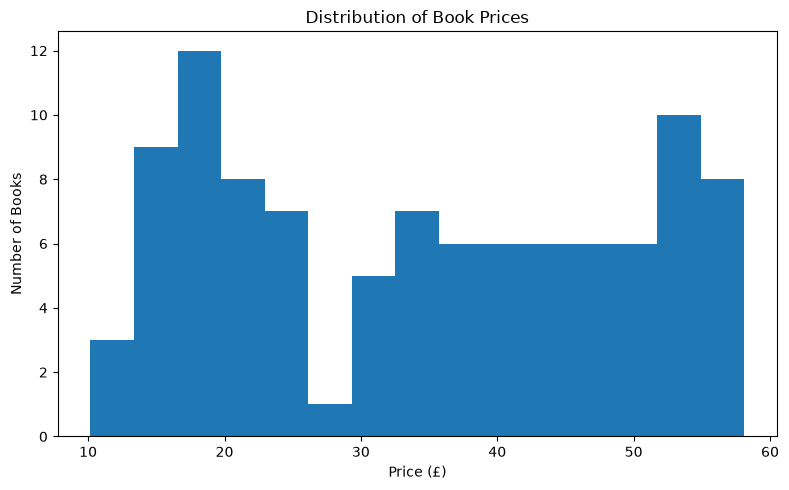

In [84]:
plt.figure(figsize=(8, 5))

plt.hist(final_df["price"], bins=15)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.tight_layout()

plt.savefig("plots/price_distribution.png", dpi=300)
plt.show()

In [85]:
import os

print(os.path.exists("plots/price_distribution.png"))

True


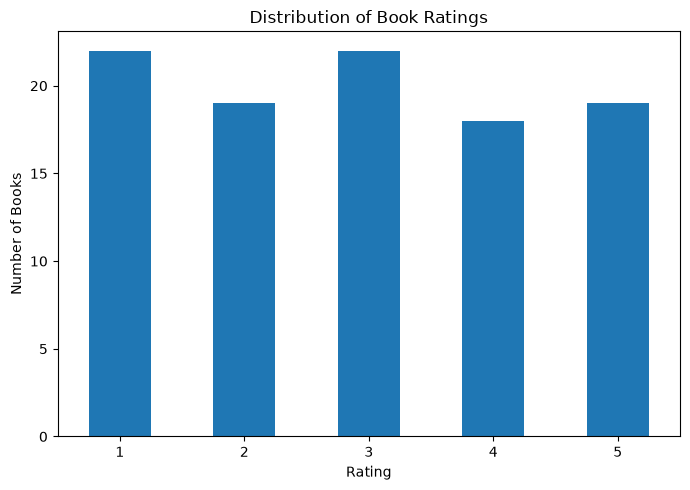

In [86]:
plt.figure(figsize=(7, 5))

rating_counts.plot(kind="bar")

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("plots/rating_distribution.png", dpi=300)
plt.show()

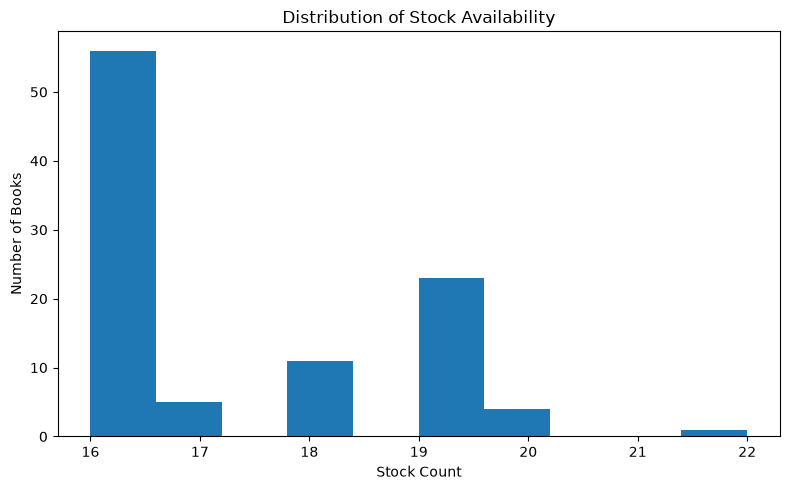

In [87]:
plt.figure(figsize=(8, 5))

plt.hist(final_df["stock_count"], bins=10)

plt.title("Distribution of Stock Availability")
plt.xlabel("Stock Count")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.savefig("plots/stock_distribution.png", dpi=300)
plt.show()

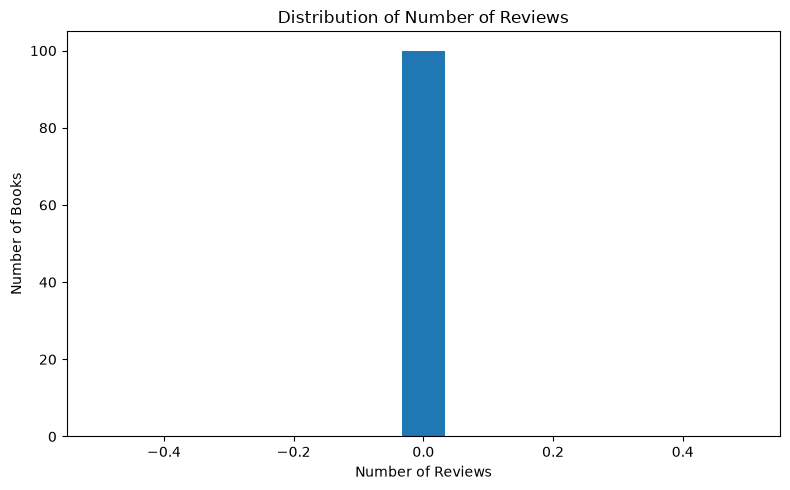

In [88]:
plt.figure(figsize=(8, 5))

plt.hist(final_df["number_of_reviews"], bins=15)

plt.title("Distribution of Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.savefig("plots/reviews_distribution.png", dpi=300)
plt.show()

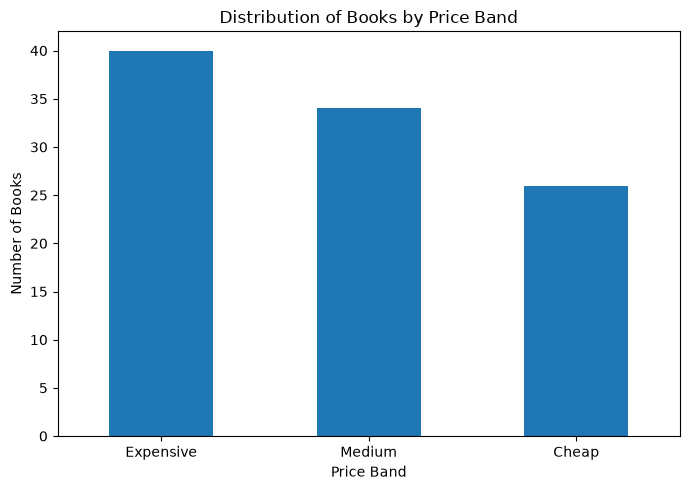

In [89]:
plt.figure(figsize=(7, 5))

price_band_counts.plot(kind="bar")

plt.title("Distribution of Books by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("plots/price_band_distribution.png", dpi=300)
plt.show()


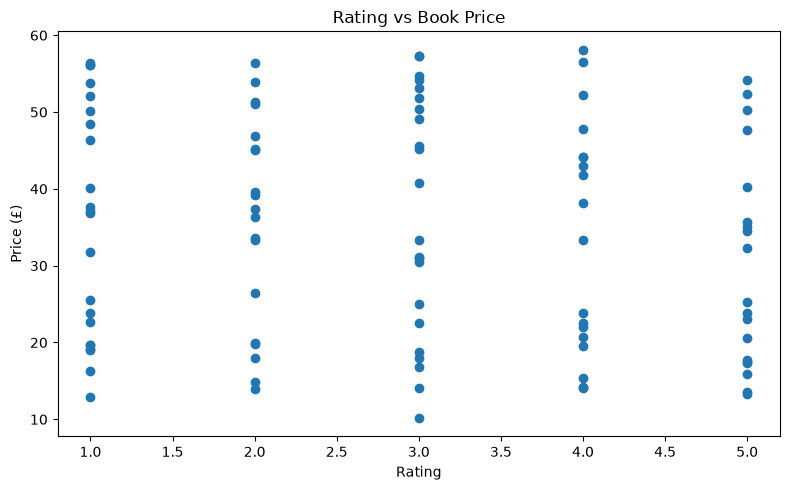

In [90]:
plt.figure(figsize=(8, 5))

plt.scatter(
    final_df["rating"],
    final_df["price"]
)

plt.title("Rating vs Book Price")
plt.xlabel("Rating")
plt.ylabel("Price (£)")

plt.tight_layout()
plt.savefig("plots/rating_vs_price.png", dpi=300)
plt.show()

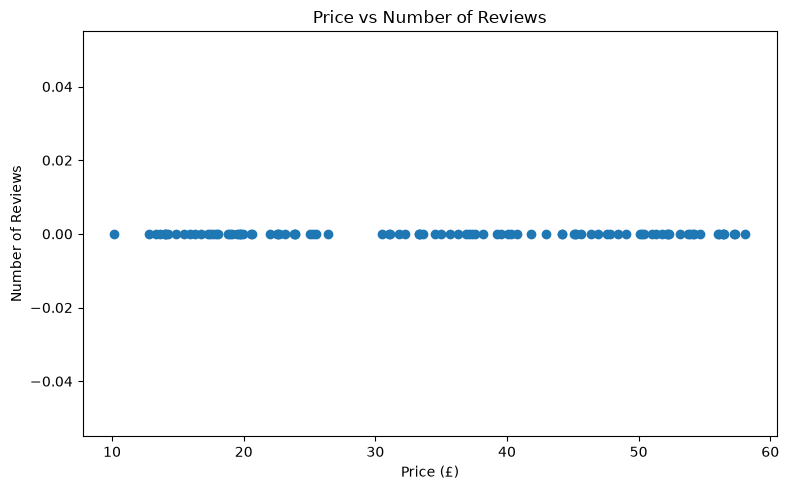

In [91]:
plt.figure(figsize=(8, 5))

plt.scatter(
    final_df["price"],
    final_df["number_of_reviews"]
)

plt.title("Price vs Number of Reviews")
plt.xlabel("Price (£)")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.savefig("plots/price_vs_reviews.png", dpi=300)
plt.show()

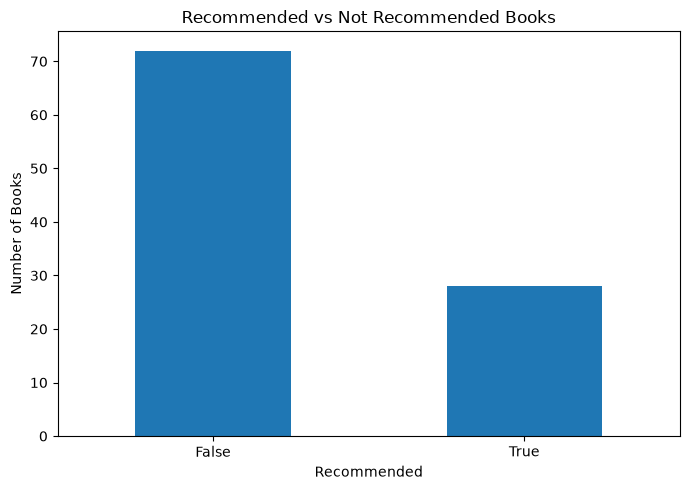

In [92]:
plt.figure(figsize=(7, 5))

recommendation_counts.plot(kind="bar")

plt.title("Recommended vs Not Recommended Books")
plt.xlabel("Recommended")
plt.ylabel("Number of Books")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("plots/recommendation_distribution.png", dpi=300)
plt.show()

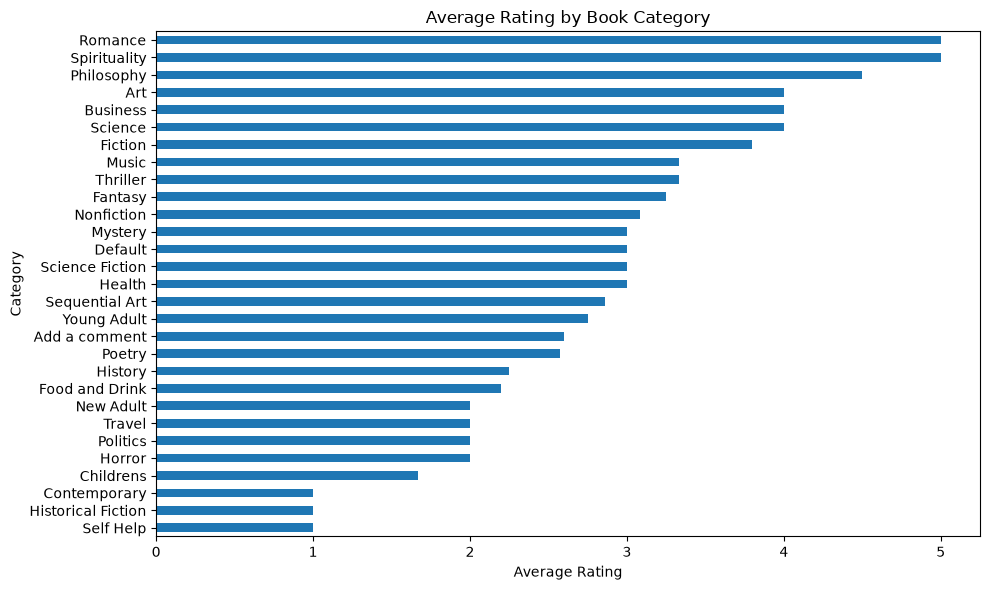

In [93]:
plt.figure(figsize=(10, 6))

category_rating["mean"].sort_values().plot(kind="barh")

plt.title("Average Rating by Book Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("plots/average_rating_by_category.png", dpi=300)
plt.show()

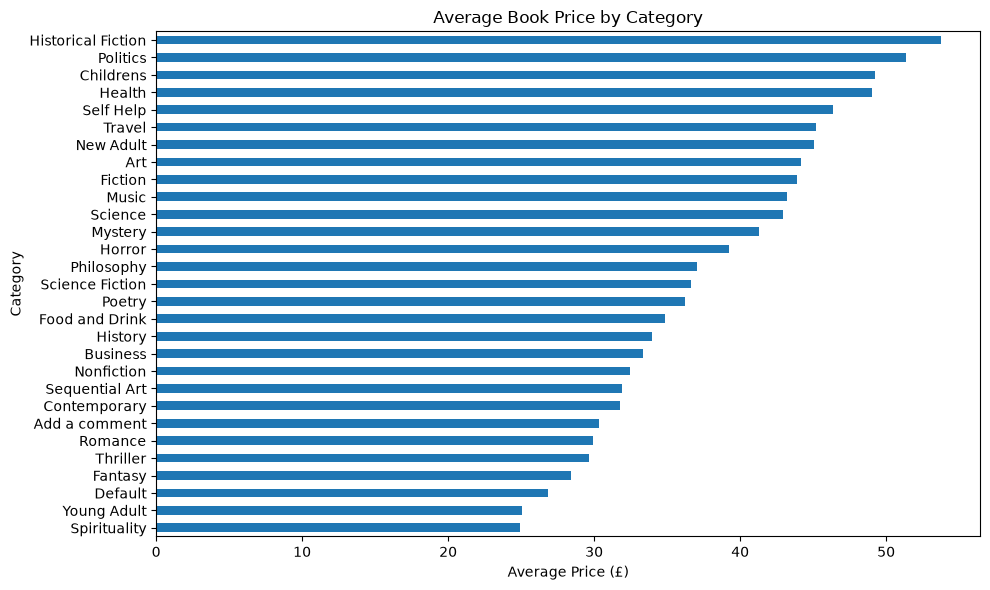

In [94]:
plt.figure(figsize=(10, 6))

category_price.sort_values().plot(kind="barh")

plt.title("Average Book Price by Category")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")

plt.tight_layout()
plt.savefig("plots/average_price_by_category.png", dpi=300)
plt.show()

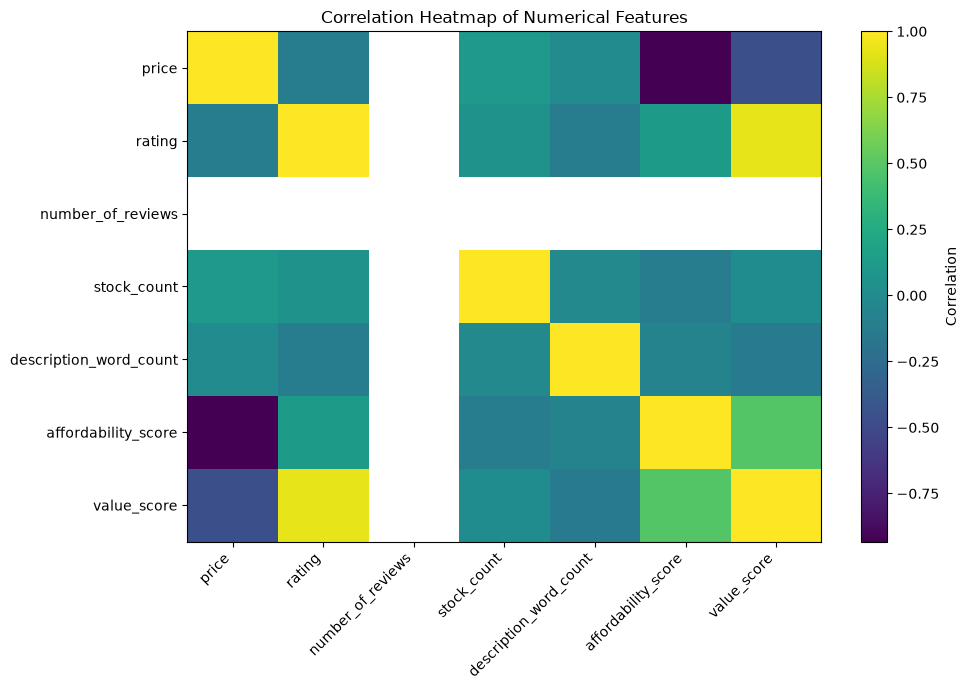

In [95]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_columns)),
    corr_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_columns)),
    corr_columns
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=300)
plt.show()

In [96]:
import os

print(os.listdir("plots"))

['average_price_by_category.png', 'average_rating_by_category.png', 'correlation_heatmap.png', 'price_band_distribution.png', 'price_distribution.png', 'price_vs_reviews.png', 'rating_distribution.png', 'rating_vs_price.png', 'recommendation_distribution.png', 'reviews_distribution.png', 'stock_distribution.png']


# Final Project Summary

## Dataset Summary

The project successfully scraped 100 books from the Books to Scrape website using Scrapy.

The final dataset contains 16 columns consisting of the original scraped attributes and engineered analytical features.

## Data Quality

- Total records: 100
- Missing values: 0
- Duplicate rows: 0
- Duplicate UPCs: 0

## Feature Engineering

The following features were created:

- `stock_count`
- `price_band`
- `affordability_score`
- `rating_score`
- `value_score`
- `affordability_norm`
- `recommended`

## Recommendation Results

72 books were classified as Recommended and 28 as Not Recommended.

Recommended books had:

- Average price: £27.00
- Average rating: 4.68
- Average value score: 0.691

Non-recommended books had:

- Average price: £37.50
- Average rating: 2.25
- Average value score: 0.268

These results indicate that the recommendation rule generally favors books with higher ratings and better affordability.

## Conclusion

This project demonstrates a complete workflow from web scraping to data analysis. Scrapy was used to collect structured book information, while Pandas and Matplotlib were used for data cleaning, feature engineering, exploratory analysis, visualization, and recommendation analysis.